In [101]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict , Literal,List, Sequence,Annotated

In [19]:
class EmployeeState(TypedDict) :
    name : str
    age: int
    salary : float 
    decision : Literal["standard_hr","forced_hr"]
    result :str

In [82]:
def analyze_employee(state : EmployeeState)->EmployeeState:
 age= state['age']
 salary=state['salary']
 if(age<=30 and salary<=40000):
  state['decision']="standard_hr"
 else:
  state['decision']="forced_hr"
 print(f"le dossierde {state['name']}a été analysé")
 return state

In [83]:
def standard_hr_process(state:EmployeeState):
    state['result'] =f"""le dossier de {state['name']}
    a été traité de manière standard"""
    print("*"*88)
    print(f" le dossier de {state['name']} a été traité de manière standard")
    print(f" Name {state['name']} salary :{state['salary']},age :{state['age']}")

    print("*"*88)

    return state 

In [102]:
def foreced_HR_validation(state:EmployeeState):
    state['result']=f"""le dossier  de {state['name']}
    a été traité de manière forcée"""
    print("="*88)
    print(f" le dossier de {state['name']} a été traité de manière forcée")
    print(f" Name : {state['name']} salary :{state['salary']},age :{state['age']}")

    print("="*88)
    return state

In [85]:
def router(state:EmployeeState):
    return state['decision']

In [86]:
workflow = StateGraph(EmployeeState)
workflow.add_node("analyse_node" ,analyze_employee)
workflow.add_node("standard_hr_node",standard_hr_process)
workflow.add_node("forced_hr_node",foreced_HR_validation)
workflow.add_edge(START,"analyse_node")
workflow.add_conditional_edges(
    "analyse_node",router,{
        "standard_hr":"standard_hr_node",
        "forced_hr":"forced_hr_node"
    }
)
workflow.add_edge("standard_hr_node",END)
workflow.add_edge("forced_hr_node",END)

graph = workflow.compile()

In [68]:
from IPython.display import Image

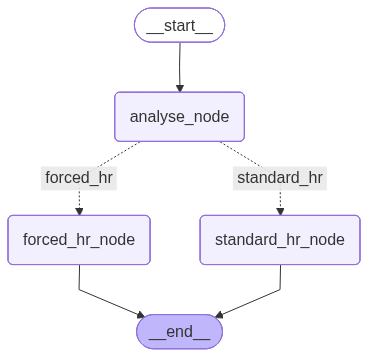

In [52]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [92]:
result = graph.invoke({
    "name":"Mohamed", "age":24,"salary":20000
})

le dossierde Mohameda été analysé
****************************************************************************************
 le dossier de Mohamed a été traité de manière standard
 Name Mohamed salary :20000,age :24
****************************************************************************************


In [93]:
print(result)

{'name': 'Mohamed', 'age': 24, 'salary': 20000, 'decision': 'standard_hr', 'result': 'le dossier de Mohamed\n    a été traité de manière standard'}


In [94]:
result = graph.invoke({
    "name":"hanane", "age":35,"salary":30000
})

le dossierde hananea été analysé
 le dossier de hanane a été traité de manière forcée
 Name : hanane salary :30000,age :35


In [96]:
print(result)

{'name': 'hanane', 'age': 35, 'salary': 30000, 'decision': 'forced_hr', 'result': 'le dossier  de hanane\n    a été traité de manière forcée'}


In [108]:
from langchain.tools import tool
from langchain.messages import SystemMessage, AIMessage,ToolMessage
from langchain_core.messages import BaseMessage,AnyMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI

In [100]:
@tool
def add(a:float , b :float ):
    """ 
    Add 2 numbers a  and  b
    """
    print(f"Adding {a} to {b}")
    return a+b


@tool
def multiply (a:float , b :float ):
    """ 
    Multiply 2 numbers a  and  b
    """
    print(f"Multiplying {a} and {b}")
    return a*b



@tool
def divide(a:float , b :float ):
    """ 
    Dividing 2 numbers a  by  b
    """
    print(f"Dividing {a} by {b}")
    return a/b
tools = [add,multiply,divide]



In [107]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages ]

In [ ]:
llm = ChatOpenAI(model="gpt-40",temperature=0)
llm_with_tools=llm.bind_tools(tools=tools)

In [109]:
def assistanr(state:AgentState)->AgentState:
    response =llm_with_tools.invoke(state['messages'])
    print("*"*50)
    print("LLM invoked ")
    return {"messages",[response]}